### Loading ad preping the data

In [5]:
import pandas as pd
import numpy as np
# %pip install hdbscan

# Loading and cleaning up the data
summary_df = pd.read_csv("summary_2.csv")
static_df = pd.read_csv("static_2.csv")
static_df['cpu'] = static_df['cpu'].replace({
    'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD': 'AMD Ryzen 7 9800X3D 8-Core Processor',
    'AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD': 'AMD Ryzen 7 5700X 8-Core Processor'
})
static_df = static_df.drop(static_df[static_df['cpu'] == 'Intel64 Family 6 Model 154 Stepping 3, GenuineIntel'].index)
static_df.to_csv("static_filtered.csv")
# Generating tables describing each machine
display(pd.crosstab(static_df["cpu"], [static_df[col] for col in ["system_ram_gb", "os"]]))
df = summary_df.merge(static_df, on = "RunID", how = "inner")
df.to_csv("summed_and_filtered.csv")
# print(df.head())

# Checking for correlation between features
display(df[["max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        "max_ram_used_mb",
        "mean_ram_used_mb"
        ]].corr())
feature_cols = [
        "mean_cpu_usage_percent",
        "mean_ram_used_mb",
        "time_per_1000_steps_sec"
    ]

system_ram_gb,8589930000,34265700000,66157800000
os,macOS,Windows 11,Windows 11
cpu,,,
AMD Ryzen 7 5700X 8-Core Processor,0,1172,0
AMD Ryzen 7 9800X3D 8-Core Processor,0,0,4237
Apple M1,99,0,0
Apple M2,302,0,0


,max_cpu_usage_percent,mean_cpu_usage_percent,max_ram_used_mb,mean_ram_used_mb
max_cpu_usage_percent,1.000000,0.929418,0.349565,0.357454
mean_cpu_usage_percent,0.929418,1.000000,0.529801,0.552533
max_ram_used_mb,0.349565,0.529801,1.000000,0.991810
mean_ram_used_mb,0.357454,0.552533,0.991810,1.000000


In [6]:
pd.crosstab(df["game_name"], df["training_type"])

training_type,ppo,sac
game_name,,
3DBall,2576,34
3DBallHard,1906,17
Crawler,401,28
GridFoodCollector,331,11
GridWorld,15,2
Hallway,128,9
PushBlock,178,8
Pyramids,34,8
Sorter,34,5


In [7]:
def create_feature_data_frame(df : pd.DataFrame) -> pd.DataFrame:
    assert (df["max_steps"] > 0).all(), "Runs with 0 steps found"
    df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)
    return df[feature_cols]
    
def get_sanitized_mask(X : pd.DataFrame):
    sanitized_mask =(
        # (X["max_cpu_usage_percent"] >= 0) &
        (X["mean_cpu_usage_percent"] >= 0) &
        # (X["max_ram_used_mb"] >= 0) &
        (X["mean_ram_used_mb"] >= 0) &
        (X["time_per_1000_steps_sec"] > 0)
    )
    return sanitized_mask

def get_subsample_mask(sanitized_df : pd.DataFrame, instances_per_machine_game_pair = 5):
    subsampled = sanitized_df.groupby(["cpu", "game_name", "training_type"], group_keys=False).apply(
        lambda x: x.sample(
            n=min(len(x), instances_per_machine_game_pair),
            random_state=42
        )
    )
    used_run_ids = set(subsampled["RunID"])
    return sanitized_df["RunID"].isin(used_run_ids)

X = create_feature_data_frame(df)
display(df["time_per_1000_steps_sec"].describe())
sanitized_mask = get_sanitized_mask(X)
X_sanitized = X[sanitized_mask].copy()
df_sanitized = df[sanitized_mask].copy()
subsample_mask = get_subsample_mask(df_sanitized)

X_sanitized = X_sanitized[subsample_mask]
df_sanitized = df_sanitized[subsample_mask]

def get_sanitized_and_subsampled_features_and_org_df(df : pd.DataFrame, subsample = True, subsample_cap = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = create_feature_data_frame(df)
    sanitized_mask = get_sanitized_mask(X)
    X_sanitized = X[sanitized_mask].copy()
    df_sanitized = df[sanitized_mask].copy()
    if subsample:
        subsample_mask = get_subsample_mask(df_sanitized, instances_per_machine_game_pair=subsample_cap)
        X_sanitized = X_sanitized[subsample_mask].copy()
        df_sanitized = df_sanitized[subsample_mask].copy()
    return X_sanitized, df_sanitized


count    5798.000000
mean        1.522229
std        15.150966
min         0.210316
25%         0.345074
50%         0.428247
75%         0.604961
max       912.552125
Name: time_per_1000_steps_sec, dtype: float64

In [8]:
filtered = (df["game_name"] == "3DBall") & (df["training_type"] == "sac")
X_sanitized[filtered].describe()

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_89863/1868267825.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_sanitized[filtered].describe()


,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
count,15.000000,15.000000,15.000000
mean,21.901292,7738.551861,11.346332
std,7.099331,6889.900097,11.245968
min,9.701604,2904.025830,2.918337
25%,17.702841,2965.551459,4.159030
50%,20.930049,3591.258325,6.029525
75%,26.581125,13410.097384,16.097085
max,33.568833,19667.491211,39.201016


In [9]:
import matplotlib.pyplot as plt

def plot_distribuiton_of_features() -> None:        
    for col in feature_cols:
        plt.figure()
        plt.hist(X[col].dropna(), bins=100)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    plt.figure()
    selected = X[X["time_per_1000_steps_sec"] > 10]
    ax = plt.axes()
    ax.set_xscale("log")
    plt.hist(selected["time_per_1000_steps_sec"].dropna(), bins=100)
    
    plt.title(f"Distribution of time_per_1000_steps_sec")
    plt.xlabel("time_per_1000_steps_sec")
    plt.ylabel("Count")
    plt.show()
    
# plot_distribuiton_of_features()


In [43]:
def generate_cluster_summary_tables(X_sanitized,df_sanitized_with_clusters):
    cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
    )
    print(pd.Series(X_sanitized["cluster"]).value_counts())
    for feature in X_sanitized.columns:
        if feature == "cluster" : continue
        print(feature)
        print(cluster_summary[feature])
    # princluster_summary)
    print(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"]))
    print(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"], normalize="index"))
    print(pd.crosstab(df_sanitized_with_clusters["cluster"], [df_sanitized_with_clusters[col] for col in ["cpu","training_type"]]))

In [11]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_scaled_df_and_np(X_sanitized : pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    scaler = RobustScaler()
    X_log = X_sanitized.copy()
    X_log["time_per_1000_steps_sec"] = np.log1p(X_log["time_per_1000_steps_sec"])
    # X_log["mean_ram_used_mb"] = np.log1p(X_log["mean_ram_used_mb"])
    X_scaled_as_array = scaler.fit_transform(X_log)
    X_scaled = pd.DataFrame(
        X_scaled_as_array,
        columns=X_sanitized.columns,
        index = X_sanitized.index
    )
    return X_scaled, X_scaled_as_array

In [12]:
def show_clustered_3d_log(X_with_clusters) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    clusters = X_with_clusters["cluster"].unique()

    for cluster in clusters:
        mask = X_with_clusters["cluster"] == cluster
        ax.scatter(
            X_with_clusters.loc[mask, "mean_cpu_usage_percent"],
            X_with_clusters.loc[mask, "mean_ram_used_mb"],
            X_with_clusters.loc[mask, "time_per_1000_steps_sec"],
            label=f"Cluster {cluster}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    # ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec", labelpad=0)

    ax.legend(title="Clusters")
    plt.show()
    
def show_by_cpu_3d_log(X) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    cpus = X["cpu"].unique()

    for cpu in cpus:
        mask = X["cpu"] == cpu
        ax.scatter(
            X.loc[mask, "mean_cpu_usage_percent"],
            X.loc[mask, "mean_ram_used_mb"],
            X.loc[mask, "time_per_1000_steps_sec"],
            label=f"CPU {cpu}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec", labelpad=0)

    ax.legend(title="CPUs")
    plt.show()



In [13]:
from sklearn.metrics import silhouette_score
# For finding proper k
k_range = range(2, 20)

inertias = []
silhouette_scores = []

X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)

for k in k_range:
    # kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X_scaled_as_array)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_as_array, labels))
    
results = pd.DataFrame({"k" : k_range, "inertia" : inertias, "silhouette_score" : silhouette_scores})

print(results)

     k     inertia  silhouette_score
0    2  416.093915          0.273196
1    3  153.450159          0.502415
2    4   98.609903          0.537518
3    5   83.105939          0.539256
4    6   67.307214          0.519778
5    7   60.990157          0.509220
6    8   46.005800          0.526636
7    9   43.103479          0.520165
8   10   39.270672          0.521202
9   11   32.950380          0.511873
10  12   30.754812          0.460445
11  13   28.703258          0.446609
12  14   25.608377          0.430247
13  15   24.855383          0.411466
14  16   23.604357          0.409433
15  17   21.592844          0.417381
16  18   20.359224          0.423788
17  19   20.248613          0.410932


In [44]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
kmeans = KMeans(n_clusters=4, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled_as_array)
X_sanitized["cluster"] = labels
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
# for feature in X_scaled.columns:
#     print(cluster_summary[feature])    
# print(cluster_summary["mean_cpu_usage_percent"])
# display(cluster_summary)
# pd.Series(labels).value_counts()
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = labels
generate_cluster_summary_tables(X_sanitized, df_sanitized_with_clusters)
# show_clustered_3d_log(X_sanitized)


cluster
1    117
2     60
0     60
3     58
Name: count, dtype: int64
mean_cpu_usage_percent
              mean        std        min        max
cluster                                            
0        22.744728  10.436504   4.636000  55.329807
1        26.417778   5.137602  16.153333  42.872490
2         7.030526   5.033327   1.737500  23.240663
3        65.585111   4.964457  53.803801  79.356251
mean_ram_used_mb
                 mean          std          min           max
cluster                                                      
0         7764.311286  5954.866689  2660.485742  19947.100000
1         3548.542988  1395.256490  2588.723328  18110.803320
2        13416.771283  4198.503534  8366.276391  23669.109756
3        21964.370833  3139.012921  4220.743938  26883.274096
time_per_1000_steps_sec
              mean         std        min         max
cluster                                              
0        63.476386  132.745053  10.646456  912.552125
1         3.266585  

In [15]:
X_sanitized.corr()
X_sanitized["cluster"].value_counts()

cluster
1    117
2     60
0     60
3     58
Name: count, dtype: int64

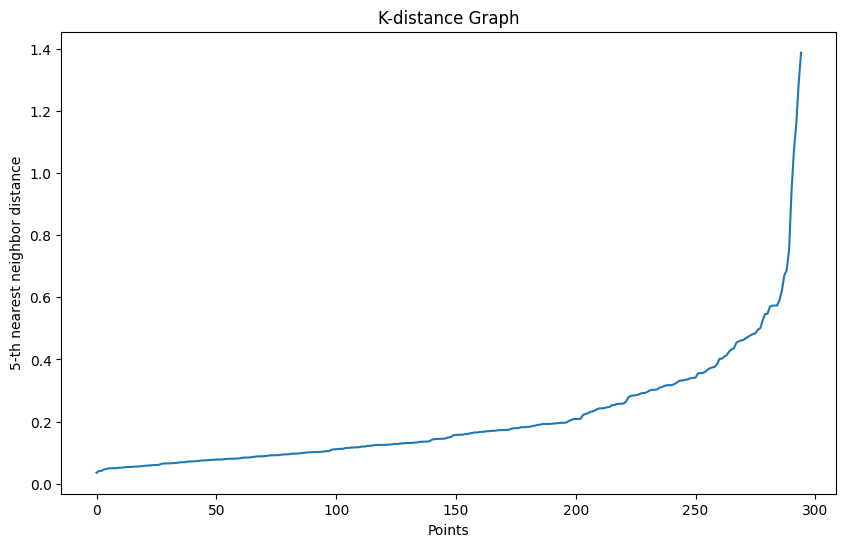

In [16]:
X_sanitized_dbscan, df_sanitized_dbscan = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled_dbscan, X_scaled_as_array_dbscan = get_scaled_df_and_np(X_sanitized_dbscan)

from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X_scaled_dbscan)
    distances, _ = neigh.kneighbors(X_scaled_dbscan)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [17]:
from sklearn.cluster import DBSCAN

def get_noise_from_eps_range(X_scaled_as_array_dbscan, eps_start, eps_end, eps_interval = 0.1) -> dict:
    noise_dict = {}
    eps_curr = eps_start
    while(eps_curr <= eps_end):            
        dbscan = DBSCAN(eps = eps_curr, min_samples = 5)
        labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
        noise_dict[eps_curr] = np.sum(labels == -1)/len(labels)
        eps_curr+=eps_interval
    return noise_dict

for k, v in get_noise_from_eps_range(X_scaled_as_array_dbscan, 0.2, 0.8).items():
    print(f"Epsilon = {k}, noise = {v}")

Epsilon = 0.2, noise = 0.26440677966101694
Epsilon = 0.30000000000000004, noise = 0.14576271186440679
Epsilon = 0.4, noise = 0.08135593220338982
Epsilon = 0.5, noise = 0.04067796610169491
Epsilon = 0.6, noise = 0.01694915254237288
Epsilon = 0.7, noise = 0.01694915254237288
Epsilon = 0.7999999999999999, noise = 0.013559322033898305


In [18]:
dbscan = DBSCAN(eps = 0.4)
labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
X_sanitized_dbscan["cluster"] = labels
df_sanitized_dbscan["cluster"] = labels

cluster_dbscan_summary = (
    X_sanitized_dbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_dbscan_summary)
X_sanitized_dbscan["cluster"].value_counts()

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   34.777333  20.572156   4.636000  73.460501   
 0                    6.003923   3.490299   1.737500  13.942750   
 1                   25.253078   7.153598   5.927114  45.424243   
 2                   66.488978   3.997335  55.889584  79.356251   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          13462.114108  6754.261744   2823.696663  20464.625000   
 0          13371.917701  4247.827063   8366.276391  23669.109756   
 1           4627.896711  3624.854132   2588.723328  19947.100000   
 2          22664.018517  1905.713449  18424.992647  26883.274096   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                   101.961703  206.340332  0.708888  912.552125  
 0                     1.334250    1.121788  0.454311    5.403695  
 1                    11.140948   14.714452  0.627457   69.295352  
 2                     0.674204    0.518991  0.226689    2.659151

cluster
 1    166
 0     55
 2     50
-1     24
Name: count, dtype: int64

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   34.777333  20.572156   4.636000  73.460501   
 0                    6.003923   3.490299   1.737500  13.942750   
 1                   25.253078   7.153598   5.927114  45.424243   
 2                   66.488978   3.997335  55.889584  79.356251   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          13462.114108  6754.261744   2823.696663  20464.625000   
 0          13371.917701  4247.827063   8366.276391  23669.109756   
 1           4627.896711  3624.854132   2588.723328  19947.100000   
 2          22664.018517  1905.713449  18424.992647  26883.274096   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                   101.961703  206.340332  0.708888  912.552125  
 0                     1.334250    1.121788  0.454311    5.403695  
 1                    11.140948   14.714452  0.627457   69.295352  
 2                     0.674204    0.518991  0.226689    2.659151

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,4,1,1,5,1,2,2,1,5,1,1
0,5,6,6,3,5,5,4,6,5,5,5
1,21,13,24,16,3,16,16,15,10,16,16
2,5,5,5,5,0,5,5,5,5,5,5


training_type,ppo,sac
cluster,,
-1,0.208333,0.791667
0,0.945455,0.054545
1,0.572289,0.427711
2,1.000000,0.000000


cpu           AMD Ryzen 7 5700X 8-Core Processor      \
training_type                                ppo sac   
cluster                                                
-1                                             3   7   
 0                                            52   3   
 1                                             0  19   
 2                                             0   0   

cpu           AMD Ryzen 7 9800X3D 8-Core Processor     Apple M1     Apple M2  \
training_type                                  ppo sac      ppo sac      ppo   
cluster                                                                        
-1                                               0   8        0   4        2   
 0                                               0   0        0   0        0   
 1                                               0   0       45  36       50   
 2                                              50   0        0   0        0   

cpu                
training_type sac  
cluster            
-1              0  
 0              0  
 1             16  
 2              0

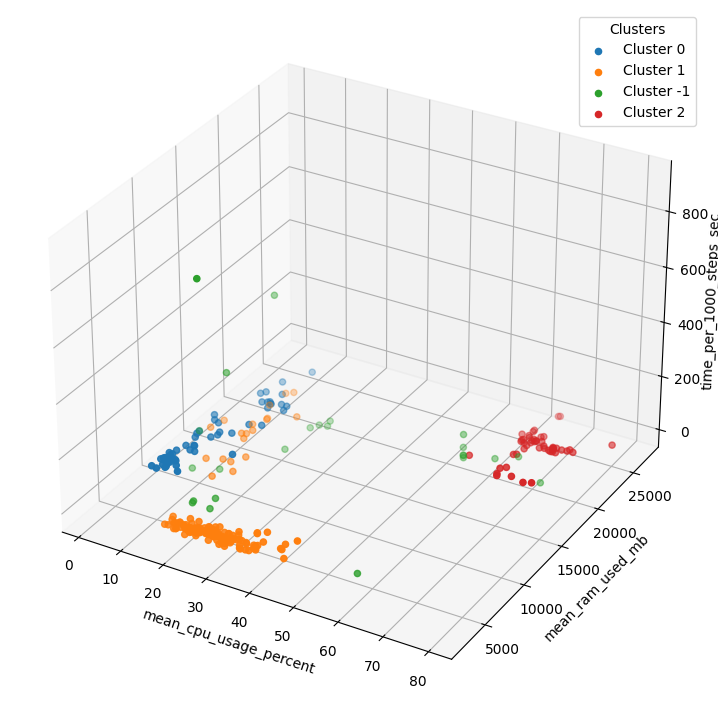

cluster
 1    166
 0     55
 2     50
-1     24
Name: count, dtype: int64


In [19]:
generate_cluster_summary_tables(X_sanitized_dbscan,df_sanitized_dbscan)
show_clustered_3d_log(X_sanitized_dbscan)
print(X_sanitized_dbscan["cluster"].value_counts())

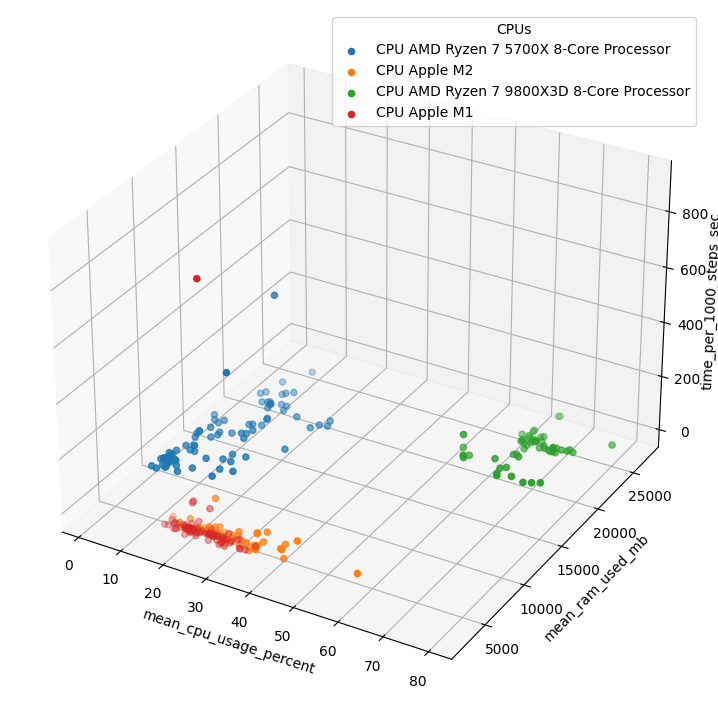

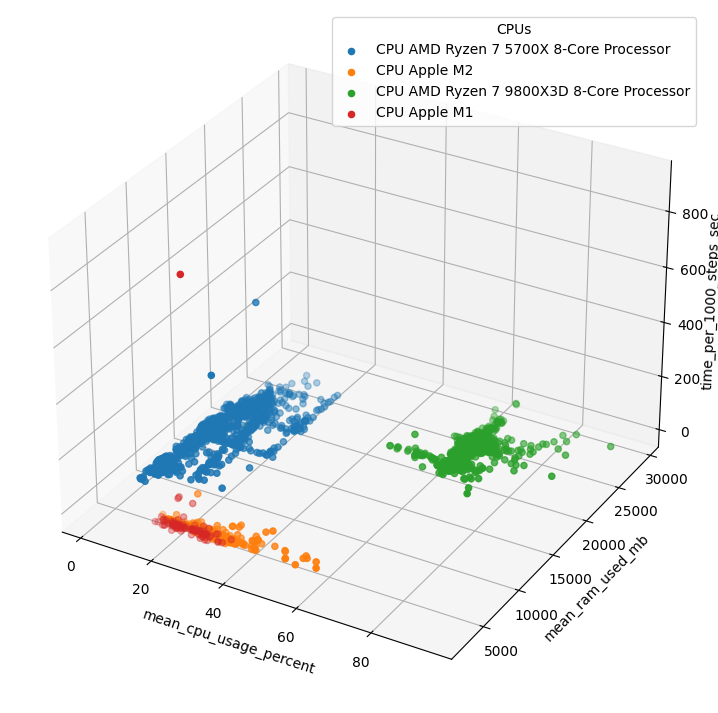

In [20]:
show_by_cpu_3d_log(df_sanitized_dbscan)
show_by_cpu_3d_log(df)